<a href="https://colab.research.google.com/github/BogdanT54/data-viz/blob/main/proiect_macro_romania_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Analiza Macroeconomică a României în Context European (2000–2026)
### Disciplina: Vizualizarea Datelor
---
**Autor:** *[Numele tău]*  
**An universitar:** 2024–2025  

> *"România a crescut economic spectaculos în 25 de ani, dar această creștere este fragilă, inegală și demografic nesustenabilă."*


---
## 📌 PUNCTUL 1 - Semnificația temei, organizarea, relevanța și coerența datelor *(1.5p)*

### 1.1 Motivația alegerii temei

România a parcurs în ultimii 25 de ani una dintre cele mai spectaculoase transformări economice din Europa Centrală și de Est: de la o economie cu inflație de **45% în 2001** la una cu inflație sub 5% în 2024, de la un PIB/cap de **~$1.600** la peste **$20.000**. Această temă este relevantă din multiple perspective:

- **Istorică:** surprinde traiectoria de la tranziția post-comunistă la statutul de stat UE și convergența europeană
- **Financiară:** evidențiază stabilitatea monetară (EUR/RON), politica BNR, piața de capital și sustenabilitatea fiscală
- **Demografică:** radiografiază bomba cu ceas demografică - îmbătrânire + emigrație - care amenință tot restul

### 1.2 Structura narativă: 4 acte

| Act | Perioadă | Tema centrală |
|-----|----------|---------------|
| **I**   | 2000–2007 | Tranziția și pregătirea pentru UE - inflație mare, creștere rapidă |
| **II**  | 2007–2012 | Aderare UE, boom și criză financiară globală |
| **III** | 2012–2021 | Consolidare cu vulnerabilități - deficit, deficit, deficit |
| **IV**  | 2021–2026 | Inflație record, presiune demografică, piață de capital în expansiune |

### 1.3 Seturile de date utilizate

| Nr. | Fișier CSV | Conținut | Frecvență | Perioadă | Sursă |
|-----|-----------|----------|-----------|----------|-------|
| 1 | `pib_nominal_anual.csv` | PIB nominal USD, creștere %, PIB/cap | Anuală | 2000–2025 | World Bank |
| 2 | `pib_trimestrial.csv` | Indice volum PIB RO + Euro Area (2020=100) | Trimestrială | 2000–2026 | Eurostat |
| 3 | `ipc_lunar.csv` | IPC lunar față de luna anterioară (%) | Lunară | 2000–2026 | INS |
| 4 | `inflatie_anuala.csv` | Rata inflației anuale (%) | Anuală | 2000–2025 | INS |
| 5 | `dobanzi_bnr.csv` | Dobânda de politică monetară BNR (%) | Lunară | 2003–2026 | BNR |
| 6 | `hicp_lunar.csv` | HICP lunar RO și UE-27 (%) | Lunară | 2000–2025 | Eurostat |
| 7 | `curs_valutar.csv` | EUR/RON, EUR/PLN, EUR/HUF zilnic + indici | Zilnică | 2005–2026 | ECB / BNR |
| 8 | `somaj_trimestrial.csv` | Rata șomajului BIM pe trimestre (%) | Trimestrială | 2000–2026 | INS |
| 9 | `salariu_minim.csv` | Salariul minim brut/net (RON) | La modificare | 2005–2026 | Legislație |
| 10 | `castig_salarial_total.csv` | Câștigul salarial mediu net lunar (RON) | Lunară | 2000–2025 | INS |
| 11 | `deficit_bugetar.csv` | Deficit bugetar RO și UE (% PIB) | Anuală | 2000–2025 | Eurostat |
| 12 | `datorie_publica.csv` | Datorie publică RO și UE (% PIB) | Anuală | 2000–2025 | Eurostat |
| 13 | `randament_10y.csv` | Randament obligațiuni stat 10Y RO și UE | Lunară | 2005–2026 | Eurostat |
| 14 | `rezerve_bnr.csv` | Rezerve internaționale totale BNR (mil. EUR) | Lunară | 2005–2026 | BNR |
| 15 | `bet_zilnic.csv` | Indicele BET - prețuri zilnice (puncte) | Zilnică | 2010–2026 | BVB |
| 16 | `capitalizare_bvb.csv` | Capitalizare bursieră BVB (mld. RON) | Anuală | 2000–2026 | BVB |
| 17 | `pmi_lunar.csv` | PMI Manufacturing Eurozonă | Lunară | 2005–2025 | S&P Global |
| 18 | `natalitate.csv` | Rata natalității (‰) | Anuală | 2000–2024 | INS |
| 19 | `populatie_grupe_varsta.csv` | Populație pe grupe de vârstă și sex | Anuală | 2003–2025 | INS |
| 20 | `emigranti.csv` | Emigranți definitivi (nr. persoane) | Anuală | 2000–2024 | INS |
| 21 | `migratie_neta.csv` | Migrație netă anuală (nr. persoane) | Anuală | 2000–2024 | Eurostat |

### 1.4 Organizarea notebook-ului

Notebook-ul urmează o structură **tematică** cu 7 capitole analitice + 1 dashboard interactiv, totalizând **15 grafice**. Toate datele sunt reale, descărcate din surse oficiale (INS, BNR, Eurostat, BVB, ECB) și pre-procesate în format CSV uniform.

> **⚠️ Notă:** Plasați toate fișierele CSV în același director cu notebook-ul înainte de rulare.


---
## ⚙️ Setup - Biblioteci și Configurare Globală


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import ipywidgets as pyw
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

print("✓ Biblioteci importate cu succes.")

✓ Biblioteci importate cu succes.


In [2]:
# ── Culori globale ──────────────────────────────────────────────
CUL = {
    'ro':      '#CC0000',
    'ue':      '#003399',
    'ea':      '#0066CC',
    'pln':     '#003087',
    'huf':     '#477050',
    'verde':   '#2E7D32',
    'rosu':    '#CC0000',
    'gri':     '#757575',
    'galben':  '#F9A825',
    'portoc':  '#E67E22',
}

# ── Ere istorice (pentru axele X anuale) ────────────────────────
ERE = [
    (2000, 2004, '#FFF3E0', 'Pre-UE'),
    (2004, 2007, '#E8F5E9', 'Negocieri'),
    (2007, 2009, '#E3F2FD', 'Post-aderare'),
    (2009, 2012, '#FFEBEE', 'Criză'),
    (2012, 2020, '#F3E5F5', 'Consolidare'),
    (2020, 2026, '#FFF8E1', 'Post-pandemic'),
]

FIGSIZE_W  = (16, 5)   # wide
FIGSIZE_SQ = (14, 6)   # standard

def adauga_ere(ax, ere=ERE, ymin=None, ymax=None):
    ylim = ax.get_ylim()
    y0 = ymin if ymin else ylim[0]
    y1 = ymax if ymax else ylim[1]
    for start, end, culoare, label in ere:
        ax.axvspan(start, end, alpha=0.25, color=culoare, zorder=0)
        ax.text((start+end)/2, y1, label, ha='center', va='top',
                fontsize=6.5, color='#555555', style='italic')

print("✓ Constante și funcții globale definite.")

✓ Constante și funcții globale definite.


---
## 📌 PUNCTUL 2 - Procesarea datelor în vederea vizualizării *(2p)*

Toate fișierele sunt în format CSV uniform - `pd.read_csv()` direct, fără procesare suplimentară. Coloanele de dată sunt parsate explicit, valorile numerice sunt verificate pentru NaN.


In [3]:
# ── PIB ─────────────────────────────────────────────────────────
df_pib_nom = pd.read_csv('pib_nominal_anual.csv')
df_pib_nom = df_pib_nom.sort_values('an').reset_index(drop=True)

df_pib_trim = pd.read_csv('pib_trimestrial.csv')
df_pib_trim['data'] = pd.to_datetime(df_pib_trim['an'].astype(str) + '-' +
    df_pib_trim['q'].map({'Q1':'01','Q2':'04','Q3':'07','Q4':'10'}))
df_pib_trim = df_pib_trim.sort_values('data').reset_index(drop=True)

# Calculăm variația trimestrială față de același trimestru al anului anterior
df_pib_trim['crestere_ro_yoy'] = df_pib_trim['pib_romania_idx'].pct_change(4) * 100
df_pib_trim['crestere_ea_yoy'] = df_pib_trim['pib_euroarea_idx'].pct_change(4) * 100

print(f"✓ PIB nominal: {df_pib_nom.shape[0]} ani | PIB trimestrial: {df_pib_trim.shape[0]} trimestre")
print(f"  PIB nominal 2024: ${df_pib_nom[df_pib_nom['an']==2024]['pib_nominal_usd'].values[0]/1e9:.1f} mld USD")
print(f"  PIB trimestrial: {df_pib_trim['trimestru'].iloc[0]} → {df_pib_trim['trimestru'].iloc[-1]}")

✓ PIB nominal: 26 ani | PIB trimestrial: 105 trimestre
  PIB nominal 2024: $382.9 mld USD
  PIB trimestrial: 2000-Q1 → 2026-Q1


In [4]:
# ── Inflație & BNR ──────────────────────────────────────────────
df_ipc = pd.read_csv('ipc_lunar.csv', parse_dates=['data'])
df_inflatie = pd.read_csv('inflatie_anuala.csv')
df_inflatie = df_inflatie[df_inflatie['an'] >= 2000].reset_index(drop=True)

df_bnr = pd.read_csv('dobanzi_bnr.csv', parse_dates=['data'])
df_bnr = df_bnr.sort_values('data').reset_index(drop=True)

df_hicp = pd.read_csv('hicp_lunar.csv', parse_dates=['data'])
df_hicp = df_hicp.sort_values('data').reset_index(drop=True)

# Merge IPC + BNR pe an-lună pentru graficul dual-axis
df_ipc['an']  = df_ipc['data'].dt.year
df_ipc['luna'] = df_ipc['data'].dt.month
df_bnr['an']  = df_bnr['data'].dt.year
df_bnr['luna'] = df_bnr['data'].dt.month
df_inf_merged = df_ipc.merge(df_bnr[['an','luna','dobanda_pm']], on=['an','luna'], how='left')

print(f"✓ IPC lunar: {df_ipc.shape[0]} luni | BNR dobânzi: {df_bnr.shape[0]} luni | HICP: {df_hicp.shape[0]} luni")
print(f"  Inflație maximă (anual): {df_inflatie['rata_inflatie_pct'].max():.1f}% în {int(df_inflatie.loc[df_inflatie['rata_inflatie_pct'].idxmax(),'an'])}")
print(f"  Dobândă BNR curentă: {df_bnr['dobanda_pm'].iloc[-1]:.2f}%")

✓ IPC lunar: 315 luni | BNR dobânzi: 280 luni | HICP: 312 luni
  Inflație maximă (anual): 45.7% în 2000
  Dobândă BNR curentă: 6.50%


In [5]:
# ── Curs Valutar ────────────────────────────────────────────────
df_curs = pd.read_csv('curs_valutar.csv', parse_dates=['data'])
df_curs = df_curs.sort_values('data').reset_index(drop=True)

# Versiune lunară (medie) pentru grafice mai clare
df_curs['an']  = df_curs['data'].dt.year
df_curs['luna'] = df_curs['data'].dt.month
df_curs_lunar = df_curs.groupby(['an','luna'])[['eur_ron','eur_pln','eur_huf','ron_idx','pln_idx','huf_idx']].mean().reset_index()
df_curs_lunar['data'] = pd.to_datetime(df_curs_lunar['an'].astype(str) + '-' + df_curs_lunar['luna'].astype(str).str.zfill(2))

print(f"✓ Curs valutar zilnic: {df_curs.shape[0]} zile | Lunar: {df_curs_lunar.shape[0]} luni")
print(f"  EUR/RON: {df_curs['eur_ron'].iloc[0]:.4f} (2005-07) → {df_curs['eur_ron'].iloc[-1]:.4f} (2026)")
print(f"  Variație EUR/RON: {((df_curs['eur_ron'].iloc[-1]/df_curs['eur_ron'].iloc[0])-1)*100:+.1f}% față de baza 2005")

✓ Curs valutar zilnic: 5342 zile | Lunar: 251 luni
  EUR/RON: 3.6030 (2005-07) → 5.2166 (2026)
  Variație EUR/RON: +44.8% față de baza 2005


In [6]:
# ── Piața Muncii ────────────────────────────────────────────────
df_somaj_trim = pd.read_csv('somaj_trimestrial.csv')
df_somaj_trim['data'] = pd.to_datetime(
    df_somaj_trim['an'].astype(str) + '-' +
    df_somaj_trim['trimestru'].map({1:'01',2:'04',3:'07',4:'10'}))
df_somaj_trim = df_somaj_trim.sort_values('data').reset_index(drop=True)

df_somaj_an = pd.read_csv('somaj_anual.csv')

df_sal_min = pd.read_csv('salariu_minim.csv')
df_sal_min = df_sal_min.sort_values(['an','luna']).reset_index(drop=True)
df_sal_min['data'] = pd.to_datetime(df_sal_min['an'].astype(str) + '-' + df_sal_min['luna'].astype(str).str.zfill(2))

df_castig = pd.read_csv('castig_salarial_total.csv')
df_castig['data'] = pd.to_datetime(df_castig['an'].astype(str) + '-' + df_castig['luna'].astype(str).str.zfill(2))
df_castig = df_castig.sort_values('data').reset_index(drop=True)

print(f"✓ Șomaj trimestrial: {df_somaj_trim.shape[0]} | Salariu minim: {df_sal_min.shape[0]} modificări")
print(f"  Câștig salarial: {df_castig.shape[0]} luni | {df_castig['data'].iloc[0].strftime('%Y-%m')} → {df_castig['data'].iloc[-1].strftime('%Y-%m')}")
print(f"  Câștig net mediu: {df_castig['castig_net_total_ron'].iloc[-1]:.0f} RON (ultima lună)")

✓ Șomaj trimestrial: 104 | Salariu minim: 21 modificări
  Câștig salarial: 312 luni | 2000-01 → 2025-12
  Câștig net mediu: 5914 RON (ultima lună)


In [7]:
# ── Finanțe Publice ─────────────────────────────────────────────
df_deficit = pd.read_csv('deficit_bugetar.csv')
df_datorie = pd.read_csv('datorie_publica.csv')
df_rand = pd.read_csv('randament_10y.csv', parse_dates=['data'])
df_rand = df_rand.sort_values('data').reset_index(drop=True)
df_rezerve = pd.read_csv('rezerve_bnr.csv', parse_dates=['data'])
df_rezerve = df_rezerve.sort_values('data').reset_index(drop=True)
df_rezerve['rezerve_mld_eur'] = df_rezerve['rezerve_total_mil_eur'] / 1000

# Merge randament + rezerve pe an-lună
df_rand['an']  = df_rand['data'].dt.year
df_rand['luna'] = df_rand['data'].dt.month
df_rezerve['an']  = df_rezerve['data'].dt.year
df_rezerve['luna'] = df_rezerve['data'].dt.month
df_rand_rez = df_rand.merge(df_rezerve[['an','luna','rezerve_mld_eur']], on=['an','luna'], how='left')

print(f"✓ Deficit: {df_deficit.shape[0]} ani | Datorie: {df_datorie.shape[0]} ani | Randament 10Y: {df_rand.shape[0]} luni")
print(f"  Deficit RO 2024: {df_deficit[df_deficit['an']==2024]['deficit_ro_pct'].values[0]}% PIB")
print(f"  Datorie RO 2024: {df_datorie[df_datorie['an']==2024]['datorie_ro_pct'].values[0]}% PIB")
print(f"  Rezerve BNR actuale: {df_rezerve['rezerve_mld_eur'].iloc[-1]:.1f} mld EUR")

✓ Deficit: 26 ani | Datorie: 26 ani | Randament 10Y: 316 luni
  Deficit RO 2024: -9.3% PIB
  Datorie RO 2024: 54.8% PIB
  Rezerve BNR actuale: 78.0 mld EUR


In [8]:
# ── Piața de Capital & PMI ───────────────────────────────────────
df_bet = pd.read_csv('bet_zilnic.csv', parse_dates=['data'])
df_bet = df_bet.sort_values('data').reset_index(drop=True)
df_bet_lunar = df_bet.set_index('data').resample('ME')['bet_pret'].mean().reset_index()

df_bvb = pd.read_csv('capitalizare_bvb.csv')
df_bvb = df_bvb.sort_values('an').reset_index(drop=True)

df_pmi = pd.read_csv('pmi_lunar.csv', parse_dates=['data'])
df_pmi = df_pmi.sort_values('data').dropna().reset_index(drop=True)
df_pmi['an'] = df_pmi['data'].dt.year
df_pmi_an = df_pmi.groupby('an')['pmi_eurozona'].mean().reset_index()

# Merge BVB + PMI anual
df_bvb_pmi = df_bvb.merge(df_pmi_an, on='an', how='left')

print(f"✓ BET zilnic: {df_bet.shape[0]} zile | Capitalizare BVB: {df_bvb.shape[0]} ani | PMI: {df_pmi.shape[0]} luni")
print(f"  BET: {df_bet['bet_pret'].iloc[0]:.0f} (mai 2010) → {df_bet['bet_pret'].iloc[-1]:.0f} puncte (mai 2026)")
print(f"  Cap. BVB 2024: {df_bvb[df_bvb['an']==2024]['capitalizare_mld_ron'].values[0]:.1f} mld RON")

✓ BET zilnic: 4006 zile | Capitalizare BVB: 27 ani | PMI: 245 luni
  BET: 4979 (mai 2010) → 30497 puncte (mai 2026)
  Cap. BVB 2024: 350.3 mld RON


In [9]:
# ── Demografie ──────────────────────────────────────────────────
df_natal = pd.read_csv('natalitate.csv')
df_pop   = pd.read_csv('populatie_grupe_varsta.csv')
df_emig  = pd.read_csv('emigranti.csv')
df_mig   = pd.read_csv('migratie_neta.csv')

# Merge demografie anuală
df_demo = df_natal.merge(df_mig, on='an', how='outer').merge(df_emig, on='an', how='outer')
df_demo = df_demo.sort_values('an').reset_index(drop=True)
df_demo['emigranti_mii'] = df_demo['emigranti_nr'] / 1000

# Piramida: date pentru 2003 și 2024
ani_piramida = [2003, 2024]
ORDINE_GRUPE = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34','35-39',
                '40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80-84','85sipeste']

print(f"✓ Natalitate: {df_natal.shape[0]} ani | Populație grupe: {df_pop.shape[0]} rânduri")
print(f"  Ani disponibili pentru piramidă: {sorted(df_pop['an'].unique())[:3]}...{sorted(df_pop['an'].unique())[-1]}")
print(f"  Grupe de vârstă: {df_pop['grupa_varsta'].nunique()} grupe")
print(f"  Emigranți 2007: {df_emig[df_emig['an']==2007]['emigranti_nr'].values[0]:,} persoane")

✓ Natalitate: 25 ani | Populație grupe: 828 rânduri
  Ani disponibili pentru piramidă: [np.int64(2003), np.int64(2004), np.int64(2005)]...2025
  Grupe de vârstă: 18 grupe
  Emigranți 2007: 8,830 persoane


---
## 📌 PUNCTUL 3 - Tipuri de diagrame și vizualizări *(2p)*

| # | Grafic | Capitol | Tip vizualizare | Date |
|---|--------|---------|-----------------|------|
| G1.1 | PIB nominal anual | PIB | Bare colorate (verde/roșu) | `pib_nominal_anual.csv` |
| G1.2 | PIB trimestrial RO vs Euro Area | PIB | Linie multi-serie | `pib_trimestrial.csv` |
| G2.1 | Inflație IPC + Dobândă BNR | Inflație | Linie ax dual | `ipc_lunar.csv` + `dobanzi_bnr.csv` |
| G2.2 | HICP lunar RO vs UE | Inflație | Linie multi-serie | `hicp_lunar.csv` |
| G3.1 | Cursuri indexate RON/PLN/HUF | Curs | Linie multi-serie | `curs_valutar.csv` |
| G4.1 | Șomaj BIM trimestrial | Muncă | Linie cu fill | `somaj_trimestrial.csv` |
| G4.2 | Salariu minim (step chart) | Muncă | Step chart | `salariu_minim.csv` |
| G4.3 | Câștig salarial net lunar | Muncă | Linie + fill | `castig_salarial_total.csv` |
| G5.1 | Deficit bugetar RO + UE + Maastricht | Finanțe | Bare grupate + linie prag | `deficit_bugetar.csv` |
| G5.2 | Datorie publică RO + UE + limita 60% | Finanțe | Linie + linie prag | `datorie_publica.csv` |
| G5.3 | Randament 10Y + Rezerve BNR | Finanțe | Linie ax dual | `randament_10y.csv` + `rezerve_bnr.csv` |
| G6.1 | Indicele BET cu crize adnotate | Capital | Linie cu adnotări | `bet_zilnic.csv` |
| G6.2 | Capitalizare BVB + PMI Eurozonă | Capital | Bare + linie ax dual | `capitalizare_bvb.csv` + `pmi_lunar.csv` |
| G7.1 | Piramida vârstelor 2003 vs 2024 | Demo | Barh back-to-back | `populatie_grupe_varsta.csv` |
| G7.2 | Natalitate + Migrație netă | Demo | Linie ax dual | `natalitate.csv` + `migratie_neta.csv` |


---
### 🏦 Capitol 1 - Produsul Intern Brut

PIB-ul nominal în USD surprinde magnitudinea creșterii absolute, iar indicele trimestrial față de Euro Area arată sincronizarea ciclică cu zona euro - inclusiv șocurile comune (2009, 2020).


#### G1.1 - PIB nominal anual România (mld. USD, 2000–2025)
**Tipul graficului:** Grafic cu bare colorate - verde pentru creștere, roșu pentru contracție  
**Mesajul:** PIB-ul s-a înzecit în 25 de ani - de la ~40 mld. USD la ~383 mld. USD.


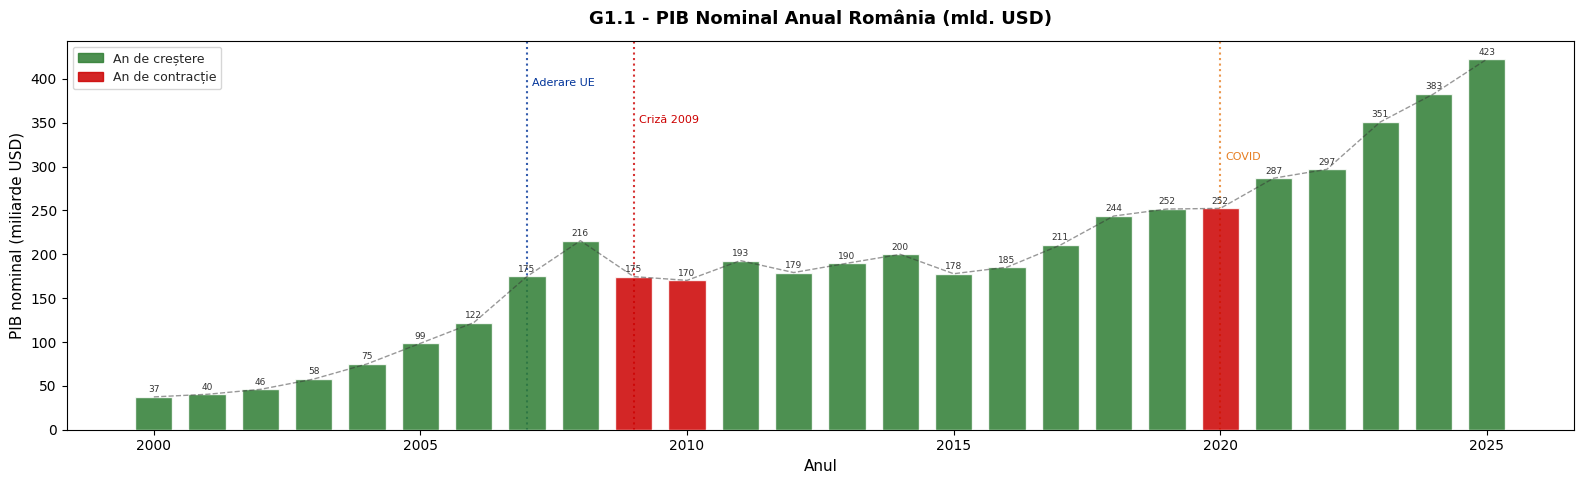

In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_p = df_pib_nom.copy()
df_p['pib_mld'] = df_p['pib_nominal_usd'] / 1e9
culori_bare = [CUL['verde'] if v > 0 else CUL['rosu'] for v in df_p['crestere_pib_pct'].fillna(1)]

ax.bar(df_p['an'], df_p['pib_mld'], color=culori_bare, alpha=0.85, width=0.7, zorder=3)

# Etichete pe bare
for _, row in df_p.iterrows():
    if not pd.isna(row['pib_mld']):
        ax.text(row['an'], row['pib_mld'] + 3, f"{row['pib_mld']:.0f}",
                ha='center', va='bottom', fontsize=6.5, color='#333333')

# Linie de tendință
ax.plot(df_p['an'], df_p['pib_mld'], color='#333333', linewidth=1, linestyle='--', alpha=0.5, zorder=4)

ax.axvline(x=2007, color=CUL['ue'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2007.1, df_p['pib_mld'].max() * 0.95, 'Aderare UE', color=CUL['ue'], fontsize=8, va='top')
ax.axvline(x=2009, color=CUL['rosu'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2009.1, df_p['pib_mld'].max() * 0.85, 'Criză 2009', color=CUL['rosu'], fontsize=8, va='top')
ax.axvline(x=2020, color=CUL['portoc'], linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(2020.1, df_p['pib_mld'].max() * 0.75, 'COVID', color=CUL['portoc'], fontsize=8, va='top')

ax.set_xlabel('Anul', fontsize=11)
ax.set_ylabel('PIB nominal (miliarde USD)', fontsize=11)
ax.set_title('G1.1 - PIB Nominal Anual România (mld. USD)', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

patch_v = mpatches.Patch(color=CUL['verde'], alpha=0.85, label='An de creștere')
patch_r = mpatches.Patch(color=CUL['rosu'], alpha=0.85, label='An de contracție')
ax.legend(handles=[patch_v, patch_r], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

#### G1.2 - PIB trimestrial: România vs. Euro Area (indice volum, 2020=100)
**Tipul graficului:** Linie multi-serie  
**Mesajul:** România crește mai rapid decât zona euro - dar și cade mai abrupt în crize.


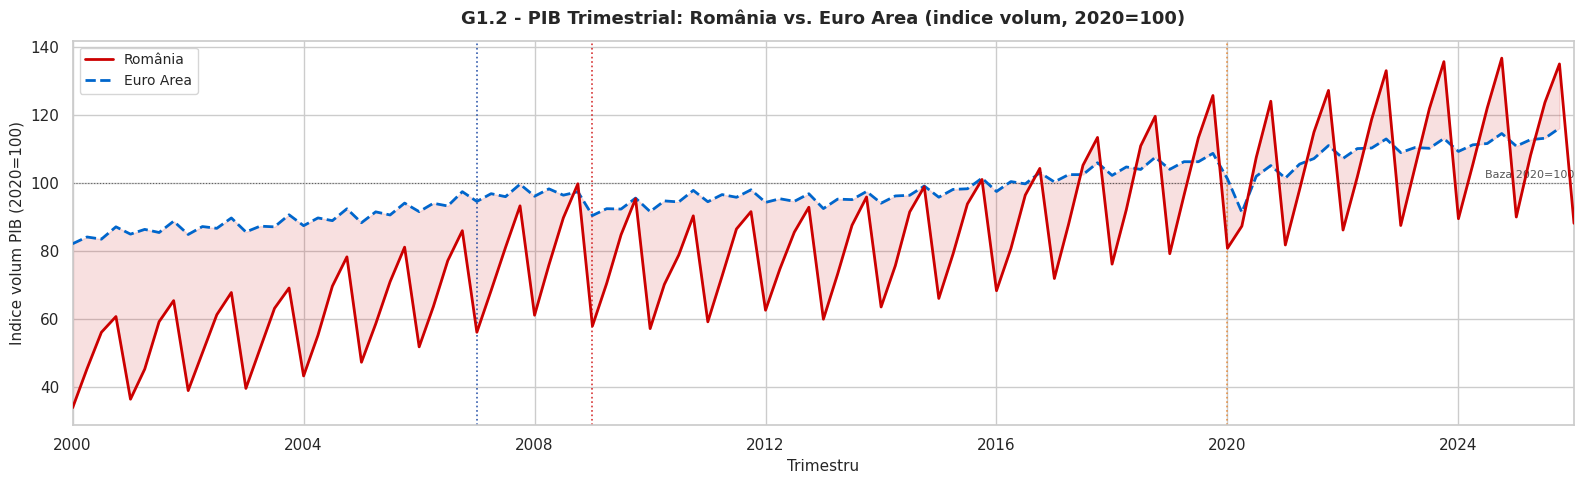

In [13]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

ax.plot(df_pib_trim['data'], df_pib_trim['pib_romania_idx'],
        color=CUL['ro'], linewidth=2, label='România', zorder=4)
ax.plot(df_pib_trim['data'], df_pib_trim['pib_euroarea_idx'],
        color=CUL['ea'], linewidth=2, linestyle='--', label='Euro Area', zorder=3)
ax.fill_between(df_pib_trim['data'], df_pib_trim['pib_romania_idx'],
                df_pib_trim['pib_euroarea_idx'], alpha=0.12, color=CUL['ro'])

ax.axhline(y=100, color='#333333', linewidth=0.8, linestyle=':', alpha=0.7)
ax.text(df_pib_trim['data'].iloc[-1], 101, 'Baza 2020=100', fontsize=8, va='bottom', ha='right', color='#555555')

for an, label, culoare, yoff in [(2009, 'Crizăglobală', CUL['rosu'], -8),
                                   (2020, 'COVID-19', CUL['portoc'], -8),
                                   (2007, 'AderareUE', CUL['ue'], 3)]:
    ax.axvline(x=pd.Timestamp(str(an)), color=culoare, linewidth=1.2, linestyle=':', alpha=0.8)

ax.set_xlabel('Trimestru', fontsize=11)
ax.set_ylabel('Indice volum PIB (2020=100)', fontsize=11)
ax.set_title('G1.2 - PIB Trimestrial: România vs. Euro Area (indice volum, 2020=100)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(df_pib_trim['data'].min(), df_pib_trim['data'].max())

plt.tight_layout()
plt.show()

---
### 📈 Capitol 2 - Inflație și Politică Monetară BNR

România a traversat trei episoade inflaționiste distincte: tranziția (2000–2004), șocul energetic pre-criză (2007–2008) și șocul post-pandemic (2022–2023, vârf 16.4%).


#### G2.1 - Inflație IPC lunar + Dobânda BNR (ax dual, 2003–2026)
**Tipul graficului:** Linie cu două axe Y (`twinx`)  
**Mesajul:** BNR reacționează cu creșteri de dobândă la fiecare episod inflaționist - lag vizibil de 2–3 trimestre.


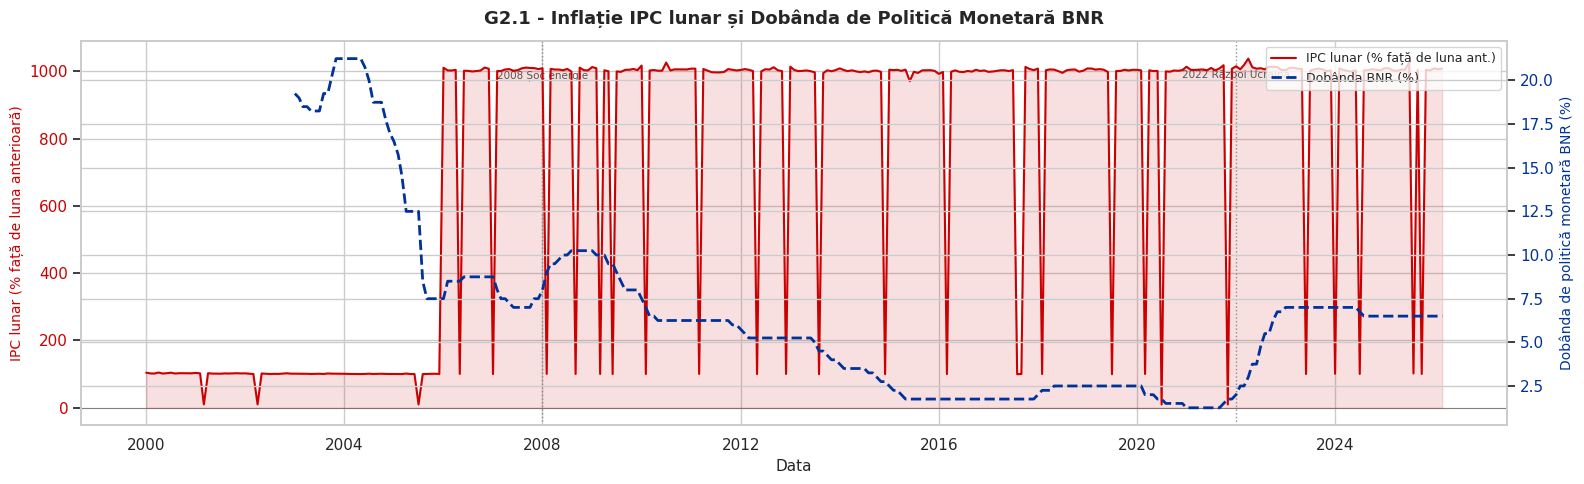

In [15]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_plot = df_inf_merged.dropna(subset=['ipc_mom']).copy()

ax1.plot(df_plot['data'], df_plot['ipc_mom'] / 10,
         color=CUL['ro'], linewidth=1.5, label='IPC lunar (% față de luna ant.)', zorder=4)
ax1.fill_between(df_plot['data'], df_plot['ipc_mom'] / 10, alpha=0.12, color=CUL['ro'])
ax1.axhline(y=0, color='#333333', linewidth=0.7, linestyle='-', alpha=0.5)
ax1.set_ylabel('IPC lunar (% față de luna anterioară)', color=CUL['ro'], fontsize=10)
ax1.tick_params(axis='y', labelcolor=CUL['ro'])

ax2 = ax1.twinx()
df_bnr_plot = df_plot.dropna(subset=['dobanda_pm'])
ax2.plot(df_bnr_plot['data'], df_bnr_plot['dobanda_pm'],
         color=CUL['ue'], linewidth=2, linestyle='--', label='Dobânda BNR (%)', zorder=3)
ax2.set_ylabel('Dobânda de politică monetară BNR (%)', color=CUL['ue'], fontsize=10)
ax2.tick_params(axis='y', labelcolor=CUL['ue'])

for an, label in [(2008, '2008 Șoc energie'), (2022, '2022 Război Ucraina')]:
    ax1.axvline(x=pd.Timestamp(str(an)), color='#777777', linewidth=1, linestyle=':', alpha=0.8)
    ax1.text(pd.Timestamp(str(an)), ax1.get_ylim()[1]*0.9, label,
             ha='center', fontsize=7.5, color='#555555')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
ax1.set_title('G2.1 - Inflație IPC lunar și Dobânda de Politică Monetară BNR', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Data', fontsize=11)

plt.tight_layout()
plt.show()

#### G2.2 - HICP lunar: România vs. UE-27 (variație lunară %, 2000–2025)
**Tipul graficului:** Linie multi-serie  
**Mesajul:** România înregistrează constant volatilitate mai mare față de media UE - structural, nu conjunctural.


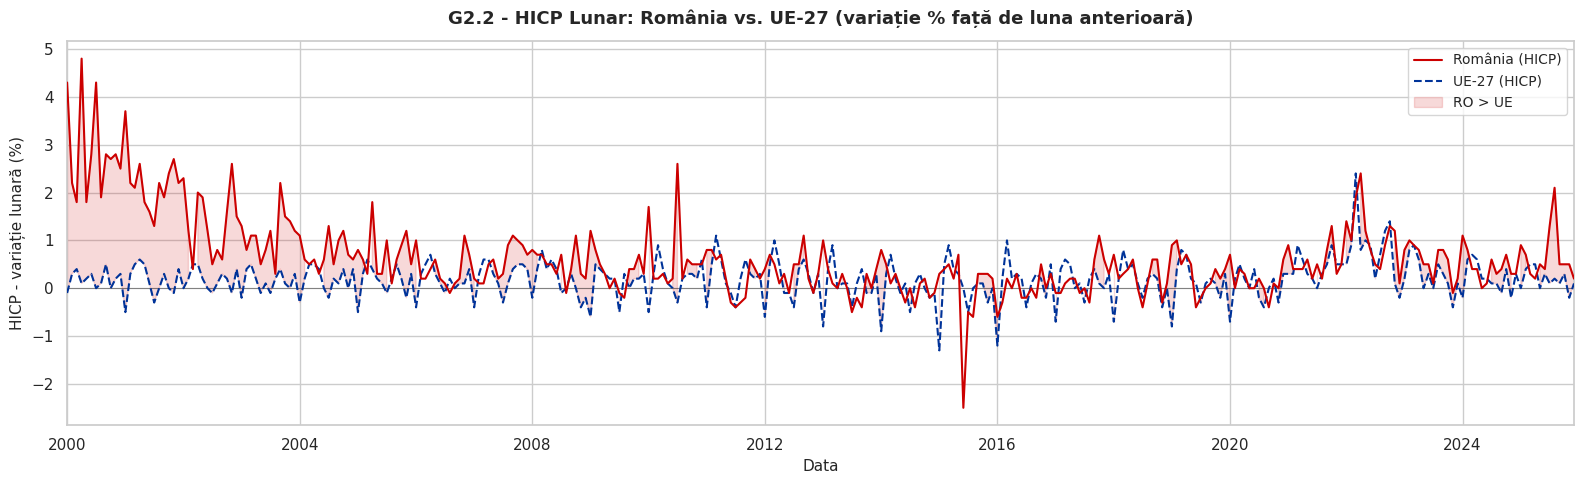

In [16]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_h = df_hicp.dropna().copy()

ax.plot(df_h['data'], df_h['hicp_ro'], color=CUL['ro'], linewidth=1.5, label='România (HICP)', zorder=4)
ax.plot(df_h['data'], df_h['hicp_ue'], color=CUL['ue'], linewidth=1.5, linestyle='--', label='UE-27 (HICP)', zorder=3)
ax.fill_between(df_h['data'], df_h['hicp_ro'], df_h['hicp_ue'],
                where=df_h['hicp_ro'] > df_h['hicp_ue'],
                alpha=0.15, color=CUL['ro'], label='RO > UE')
ax.axhline(y=0, color='#333333', linewidth=0.7, linestyle='-', alpha=0.5)

ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('HICP - variație lunară (%)', fontsize=11)
ax.set_title('G2.2 - HICP Lunar: România vs. UE-27 (variație % față de luna anterioară)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(df_h['data'].min(), df_h['data'].max())

plt.tight_layout()
plt.show()

---
### 💱 Capitol 3 - Curs Valutar

EUR/RON a rămas remarcabil de stabil față de PLN și HUF - o anomalie regională care generează atât avantaje (predictibilitate) cât și întrebări despre supraevaluare și flexibilitate economică.


#### G3.1 - Cursuri indexate EUR/RON, EUR/PLN, EUR/HUF (baza iulie 2005=100)
**Tipul graficului:** Linie multi-serie pe date lunare  
**Mesajul:** RON s-a depreciat moderat față de EUR, în timp ce PLN și HUF au oscilat violent - mai ales HUF după 2022.


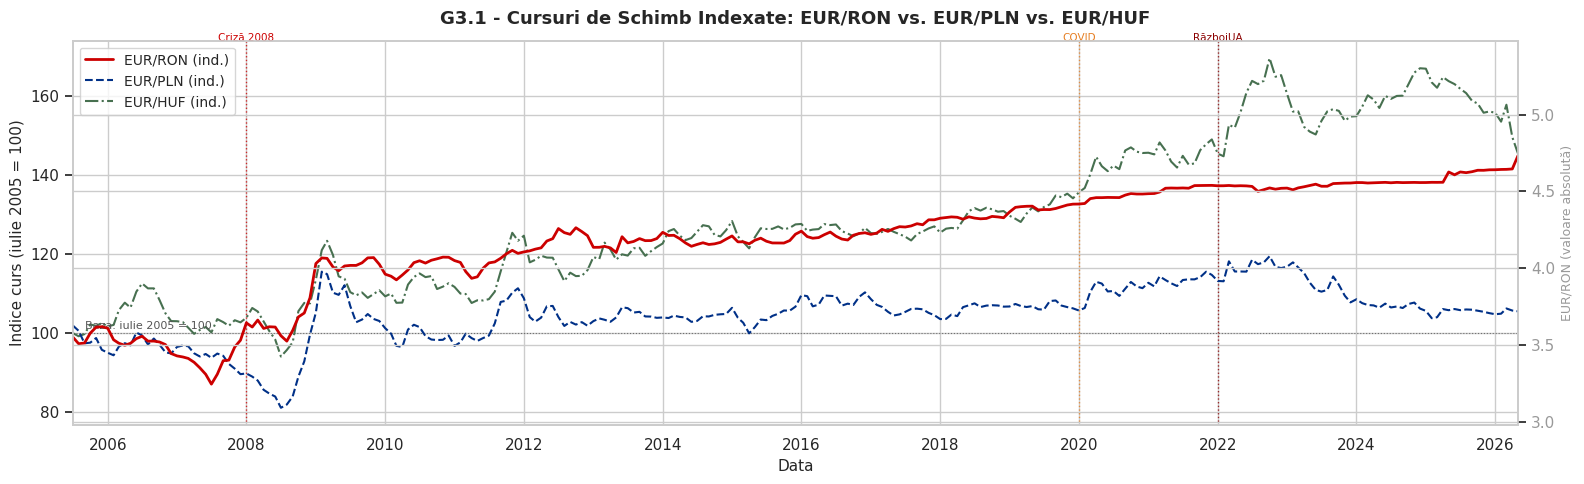

In [26]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

ax.plot(df_curs_lunar['data'], df_curs_lunar['ron_idx'],
        color=CUL['ro'], linewidth=2, label='EUR/RON (ind.)', zorder=5)
ax.plot(df_curs_lunar['data'], df_curs_lunar['pln_idx'],
        color=CUL['pln'], linewidth=1.5, linestyle='--', label='EUR/PLN (ind.)', zorder=4)
ax.plot(df_curs_lunar['data'], df_curs_lunar['huf_idx'],
        color=CUL['huf'], linewidth=1.5, linestyle='-.', label='EUR/HUF (ind.)', zorder=3)

ax.axhline(y=100, color='#333333', linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(df_curs_lunar['data'].iloc[2], 101, 'Baza: iulie 2005 = 100', fontsize=8, color='#555555')

for an, label, culoare in [(2008, 'Criză 2008', CUL['rosu']),
                            (2020, 'COVID', CUL['portoc']),
                            (2022, 'RăzboiUA', '#8B0000')]:
    ax.axvline(x=pd.Timestamp(str(an)), color=culoare, linewidth=1, linestyle=':', alpha=0.8)
    ax.text(pd.Timestamp(str(an)), ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 160,
            label, ha='center', fontsize=7.5, color=culoare)

ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Indice curs (iulie 2005 = 100)', fontsize=11)
ax.set_title('G3.1 - Cursuri de Schimb Indexate: EUR/RON vs. EUR/PLN vs. EUR/HUF', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(df_curs_lunar['data'].min(), df_curs_lunar['data'].max())

ax2 = ax.twinx()
ax2.set_ylabel('EUR/RON (valoare absolută)', color='#999999', fontsize=9)
ax2.plot(df_curs_lunar['data'], df_curs_lunar['eur_ron'], color='#999999', linewidth=0, alpha=0)
ax2.set_ylim(df_curs_lunar['eur_ron'].min() * 0.95, df_curs_lunar['eur_ron'].max() * 1.05)
ax2.tick_params(axis='y', labelcolor='#999999')

plt.tight_layout()
plt.show()

---
### 👷 Capitol 4 - Piața Muncii

O poveste în trei acte: șomaj ridicat la tranziție, scădere după aderarea UE (cu milioane de emigranți), și o piață a muncii tensionată post-2017 - salarii în creștere rapidă, șomaj structural scăzut.


#### G4.1 - Rata Șomajului BIM trimestrial (%, 2000–2025)
**Tipul graficului:** Linie cu fill sub curbă  
**Mesajul:** Șomajul a scăzut constant după 2013 - dar emigrația a contribuit la această reducere, nu doar crearea de locuri de muncă.


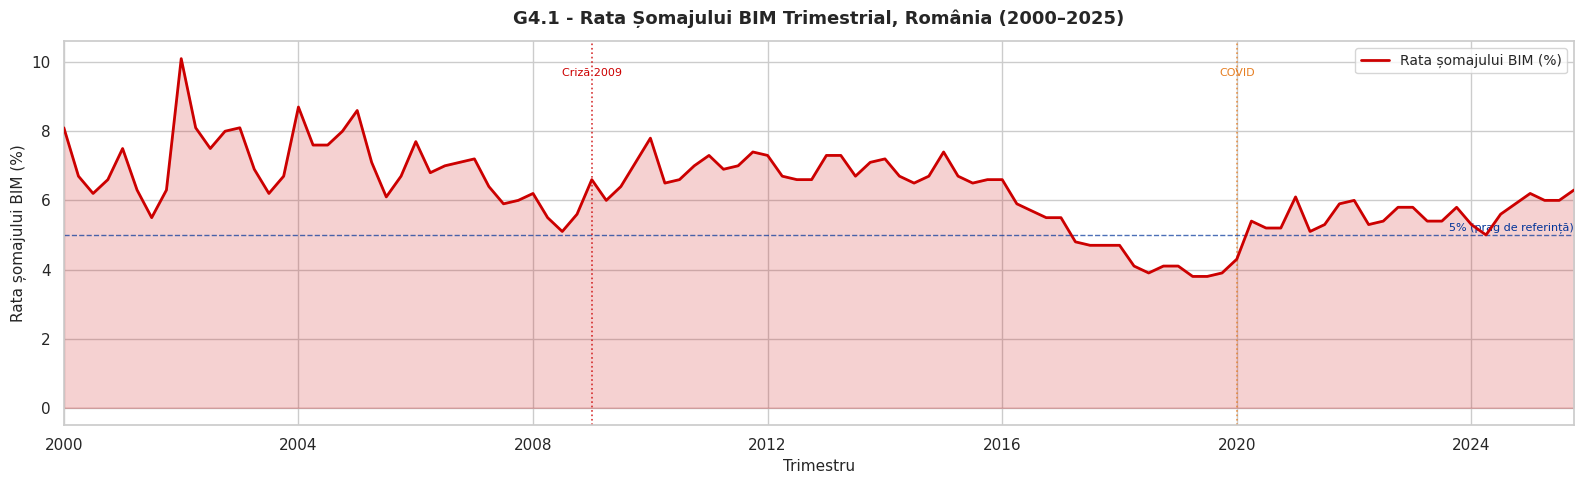

In [25]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

ax.plot(df_somaj_trim['data'], df_somaj_trim['somaj_pct'],
        color=CUL['ro'], linewidth=2, zorder=4, label='Rata șomajului BIM (%)')
ax.fill_between(df_somaj_trim['data'], df_somaj_trim['somaj_pct'],
                alpha=0.18, color=CUL['ro'])

ax.axhline(y=5, color=CUL['ue'], linewidth=1, linestyle='--', alpha=0.7)
ax.text(df_somaj_trim['data'].iloc[-1], 5.15, '5% (prag de referință)',
        ha='right', fontsize=8, color=CUL['ue'])

for an, label, culoare in [(2009, 'Criză 2009', CUL['rosu']),
                            (2020, 'COVID', CUL['portoc'])]:
    ax.axvline(x=pd.Timestamp(str(an)), color=culoare, linewidth=1.2, linestyle=':', alpha=0.8)
    ax.text(pd.Timestamp(str(an)), df_somaj_trim['somaj_pct'].max() * 0.95,
            label, ha='center', fontsize=8, color=culoare)

ax.set_xlabel('Trimestru', fontsize=11)
ax.set_ylabel('Rata șomajului BIM (%)', fontsize=11)
ax.set_title('G4.1 - Rata Șomajului BIM Trimestrial, România (2000–2025)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_xlim(df_somaj_trim['data'].min(), df_somaj_trim['data'].max())

plt.tight_layout()
plt.show()

#### G4.2 - Salariul Minim pe Economie (RON brut, step chart)
**Tipul graficului:** Step chart - fiecare modificare legislativă e vizibilă ca salt  
**Mesajul:** Salariul minim a crescut de ~14× în 20 de ani - de la 310 RON (2005) la 4.325 RON (2026).


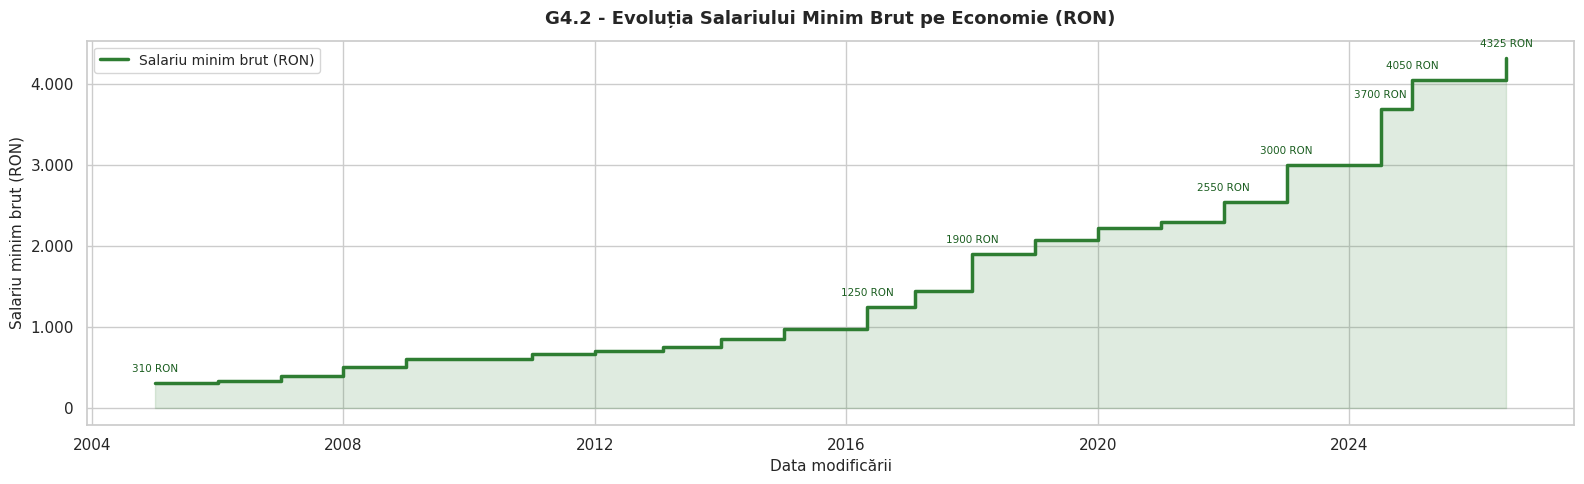

In [20]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_s = df_sal_min.dropna(subset=['salariu_minim_brut_ron']).sort_values('data')

ax.step(df_s['data'], df_s['salariu_minim_brut_ron'],
        color=CUL['verde'], linewidth=2.5, where='post', label='Salariu minim brut (RON)', zorder=4)
ax.fill_between(df_s['data'], df_s['salariu_minim_brut_ron'],
                step='post', alpha=0.15, color=CUL['verde'])

# Etichete la salturi mari
prev = 0
for _, row in df_s.iterrows():
    val = row['salariu_minim_brut_ron']
    if val - prev > 200:
        ax.annotate(f"{int(val)} RON",
                    xy=(row['data'], val),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=7.5, color='#1B5E20')
    prev = val

ax.set_xlabel('Data modificării', fontsize=11)
ax.set_ylabel('Salariu minim brut (RON)', fontsize=11)
ax.set_title('G4.2 - Evoluția Salariului Minim Brut pe Economie (RON)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))

plt.tight_layout()
plt.show()

#### G4.3 - Câștigul Salarial Mediu Net Lunar (RON, 2000–2025)
**Tipul graficului:** Linie cu fill și medie mobilă  
**Mesajul:** Salariul net mediu a crescut de ~34× în 25 de ani - de la 173 RON (2000) la ~5.900 RON (2025).


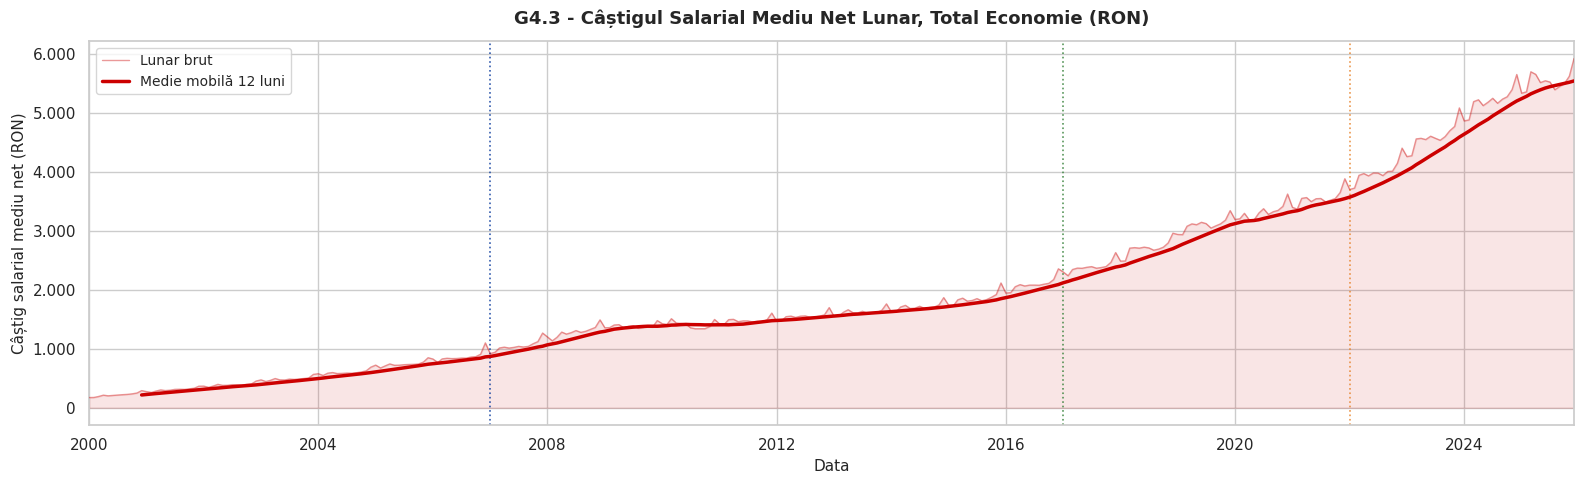

In [27]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_c = df_castig.copy()
df_c['medie_mobila_12'] = df_c['castig_net_total_ron'].rolling(12).mean()

ax.plot(df_c['data'], df_c['castig_net_total_ron'],
        color=CUL['ro'], linewidth=1, alpha=0.4, label='Lunar brut', zorder=3)
ax.plot(df_c['data'], df_c['medie_mobila_12'],
        color=CUL['ro'], linewidth=2.5, label='Medie mobilă 12 luni', zorder=4)
ax.fill_between(df_c['data'], df_c['castig_net_total_ron'], alpha=0.1, color=CUL['ro'])

# Marcăm câteva momente cheie
for an, val_label, culoare in [(2007, 'Aderare UE', CUL['ue']),
                                (2017, 'Boom salarial', CUL['verde']),
                                (2022, 'Inflație record', CUL['portoc'])]:
    ax.axvline(x=pd.Timestamp(str(an)), color=culoare, linewidth=1.2, linestyle=':', alpha=0.8)

ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('Câștig salarial mediu net (RON)', fontsize=11)
ax.set_title('G4.3 - Câștigul Salarial Mediu Net Lunar, Total Economie (RON)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',','.')))
ax.set_xlim(df_c['data'].min(), df_c['data'].max())

plt.tight_layout()
plt.show()

---
### 🏛️ Capitol 5 - Finanțe Publice

România a depășit limita Maastricht de -3% deficit bugetar în 7 din ultimii 10 ani. Datoria publică rămâne sub 60%, dar traiectoria e ascendentă. Randamentul obligațiunilor reflectă percepția de risc - în creștere față de media UE.


#### G5.1 - Deficit Bugetar: România vs. UE-27 (% PIB, 2000–2025)
**Tipul graficului:** Bare grupate + linie prag Maastricht (-3%)  
**Mesajul:** România a depășit limita de -3% repetat - și în 2024 a atins -9.3% PIB, cel mai mare din UE.


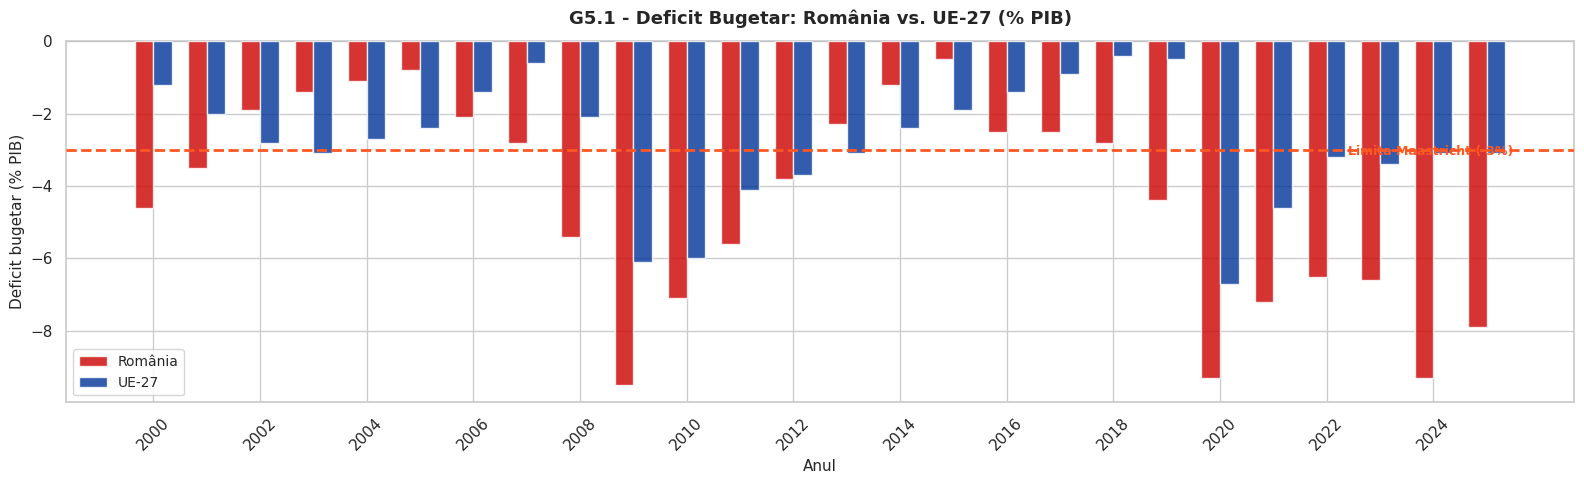

In [28]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_d = df_deficit.copy()
x = df_d['an'].values
width = 0.35

bars_ro = ax.bar(x - width/2, df_d['deficit_ro_pct'], width, label='România',
                  color=CUL['ro'], alpha=0.8, zorder=3)
bars_ue = ax.bar(x + width/2, df_d['deficit_ue_pct'], width, label='UE-27',
                  color=CUL['ue'], alpha=0.8, zorder=3)

ax.axhline(y=-3, color='#FF5722', linewidth=2, linestyle='--', zorder=5)
ax.text(x[-1] + 0.5, -3.15, 'Limita Maastricht (-3%)',
        ha='right', fontsize=9, color='#FF5722', fontweight='bold')
ax.axhline(y=0, color='#333333', linewidth=0.7, alpha=0.5)

ax.set_xlabel('Anul', fontsize=11)
ax.set_ylabel('Deficit bugetar (% PIB)', fontsize=11)
ax.set_title('G5.1 - Deficit Bugetar: România vs. UE-27 (% PIB)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_xticks(x[::2])
ax.set_xticklabels(x[::2], rotation=45)

plt.tight_layout()
plt.show()

#### G5.2 - Datorie Publică: România vs. UE-27 (% PIB, 2000–2025)
**Tipul graficului:** Linie multi-serie cu prag la 60%  
**Mesajul:** România rămâne sub 60%, dar traiectoria e accelerată - de la 18% (2007) la 52% (2025).


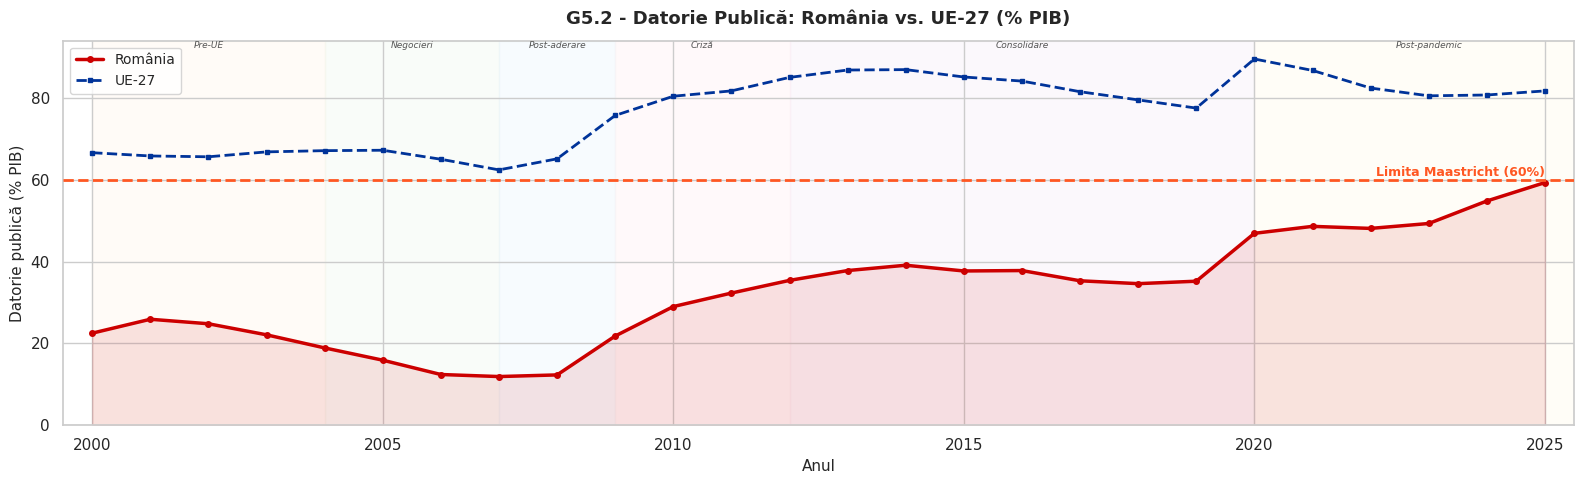

In [29]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_dat = df_datorie.copy()

ax.plot(df_dat['an'], df_dat['datorie_ro_pct'], color=CUL['ro'], linewidth=2.5,
        marker='o', markersize=4, label='România', zorder=4)
ax.plot(df_dat['an'], df_dat['datorie_ue_pct'], color=CUL['ue'], linewidth=2,
        linestyle='--', marker='s', markersize=3, label='UE-27', zorder=3)
ax.fill_between(df_dat['an'], df_dat['datorie_ro_pct'], alpha=0.1, color=CUL['ro'])

ax.axhline(y=60, color='#FF5722', linewidth=2, linestyle='--', zorder=5)
ax.text(df_dat['an'].iloc[-1], 61, 'Limita Maastricht (60%)',
        ha='right', fontsize=9, color='#FF5722', fontweight='bold')

adauga_ere(ax, ymin=0, ymax=ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 100)

ax.set_xlabel('Anul', fontsize=11)
ax.set_ylabel('Datorie publică (% PIB)', fontsize=11)
ax.set_title('G5.2 - Datorie Publică: România vs. UE-27 (% PIB)', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_xlim(df_dat['an'].min() - 0.5, df_dat['an'].max() + 0.5)
ax.set_ylim(0)

plt.tight_layout()
plt.show()

#### G5.3 - Randament Obligațiuni Stat 10Y + Rezerve BNR (ax dual)
**Tipul graficului:** Linie randamente (stânga) + linie rezerve (dreapta)  
**Mesajul:** Spread-ul RO față de UE crește - semnalând percepție de risc în creștere. Rezervele BNR tampoanizează.


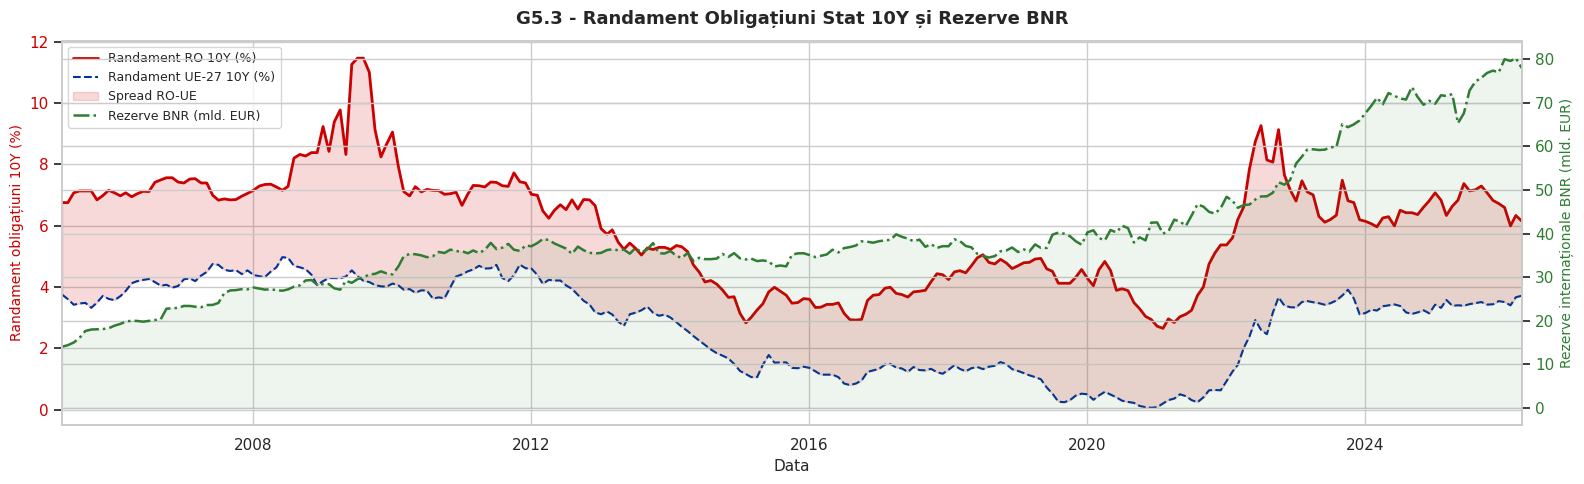

In [30]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_r = df_rand_rez.dropna(subset=['rand_ro_pct']).copy()

ax1.plot(df_r['data'], df_r['rand_ro_pct'], color=CUL['ro'], linewidth=2, label='Randament RO 10Y (%)', zorder=4)
ax1.plot(df_r['data'], df_r['rand_ue_pct'], color=CUL['ue'], linewidth=1.5, linestyle='--',
         label='Randament UE-27 10Y (%)', zorder=3)
ax1.fill_between(df_r['data'], df_r['rand_ro_pct'], df_r['rand_ue_pct'],
                  where=df_r['rand_ro_pct'] > df_r['rand_ue_pct'],
                  alpha=0.15, color=CUL['ro'], label='Spread RO-UE')
ax1.set_ylabel('Randament obligațiuni 10Y (%)', color=CUL['ro'], fontsize=10)
ax1.tick_params(axis='y', labelcolor=CUL['ro'])

ax2 = ax1.twinx()
df_rez_plot = df_rand_rez.dropna(subset=['rezerve_mld_eur'])
ax2.plot(df_rez_plot['data'], df_rez_plot['rezerve_mld_eur'],
         color=CUL['verde'], linewidth=1.8, linestyle='-.', label='Rezerve BNR (mld. EUR)', zorder=2)
ax2.fill_between(df_rez_plot['data'], df_rez_plot['rezerve_mld_eur'], alpha=0.08, color=CUL['verde'])
ax2.set_ylabel('Rezerve internaționale BNR (mld. EUR)', color=CUL['verde'], fontsize=10)
ax2.tick_params(axis='y', labelcolor=CUL['verde'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_xlabel('Data', fontsize=11)
ax1.set_title('G5.3 - Randament Obligațiuni Stat 10Y și Rezerve BNR', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlim(df_r['data'].min(), df_r['data'].max())

plt.tight_layout()
plt.show()

---
### 📊 Capitol 6 - Piața de Capital și Clima Economică

BVB a crescut de ~6× în 15 ani. PMI-ul Eurozonei anticipează ciclul economic global - România e sincronizată cu acesta.


#### G6.1 - Indicele BET (2010–2026) cu crize adnotate
**Tipul graficului:** Linie cu adnotări și fill  
**Mesajul:** BET a pierdut 50% în COVID, a recuperat în 18 luni și a atins maximul istoric în 2026.


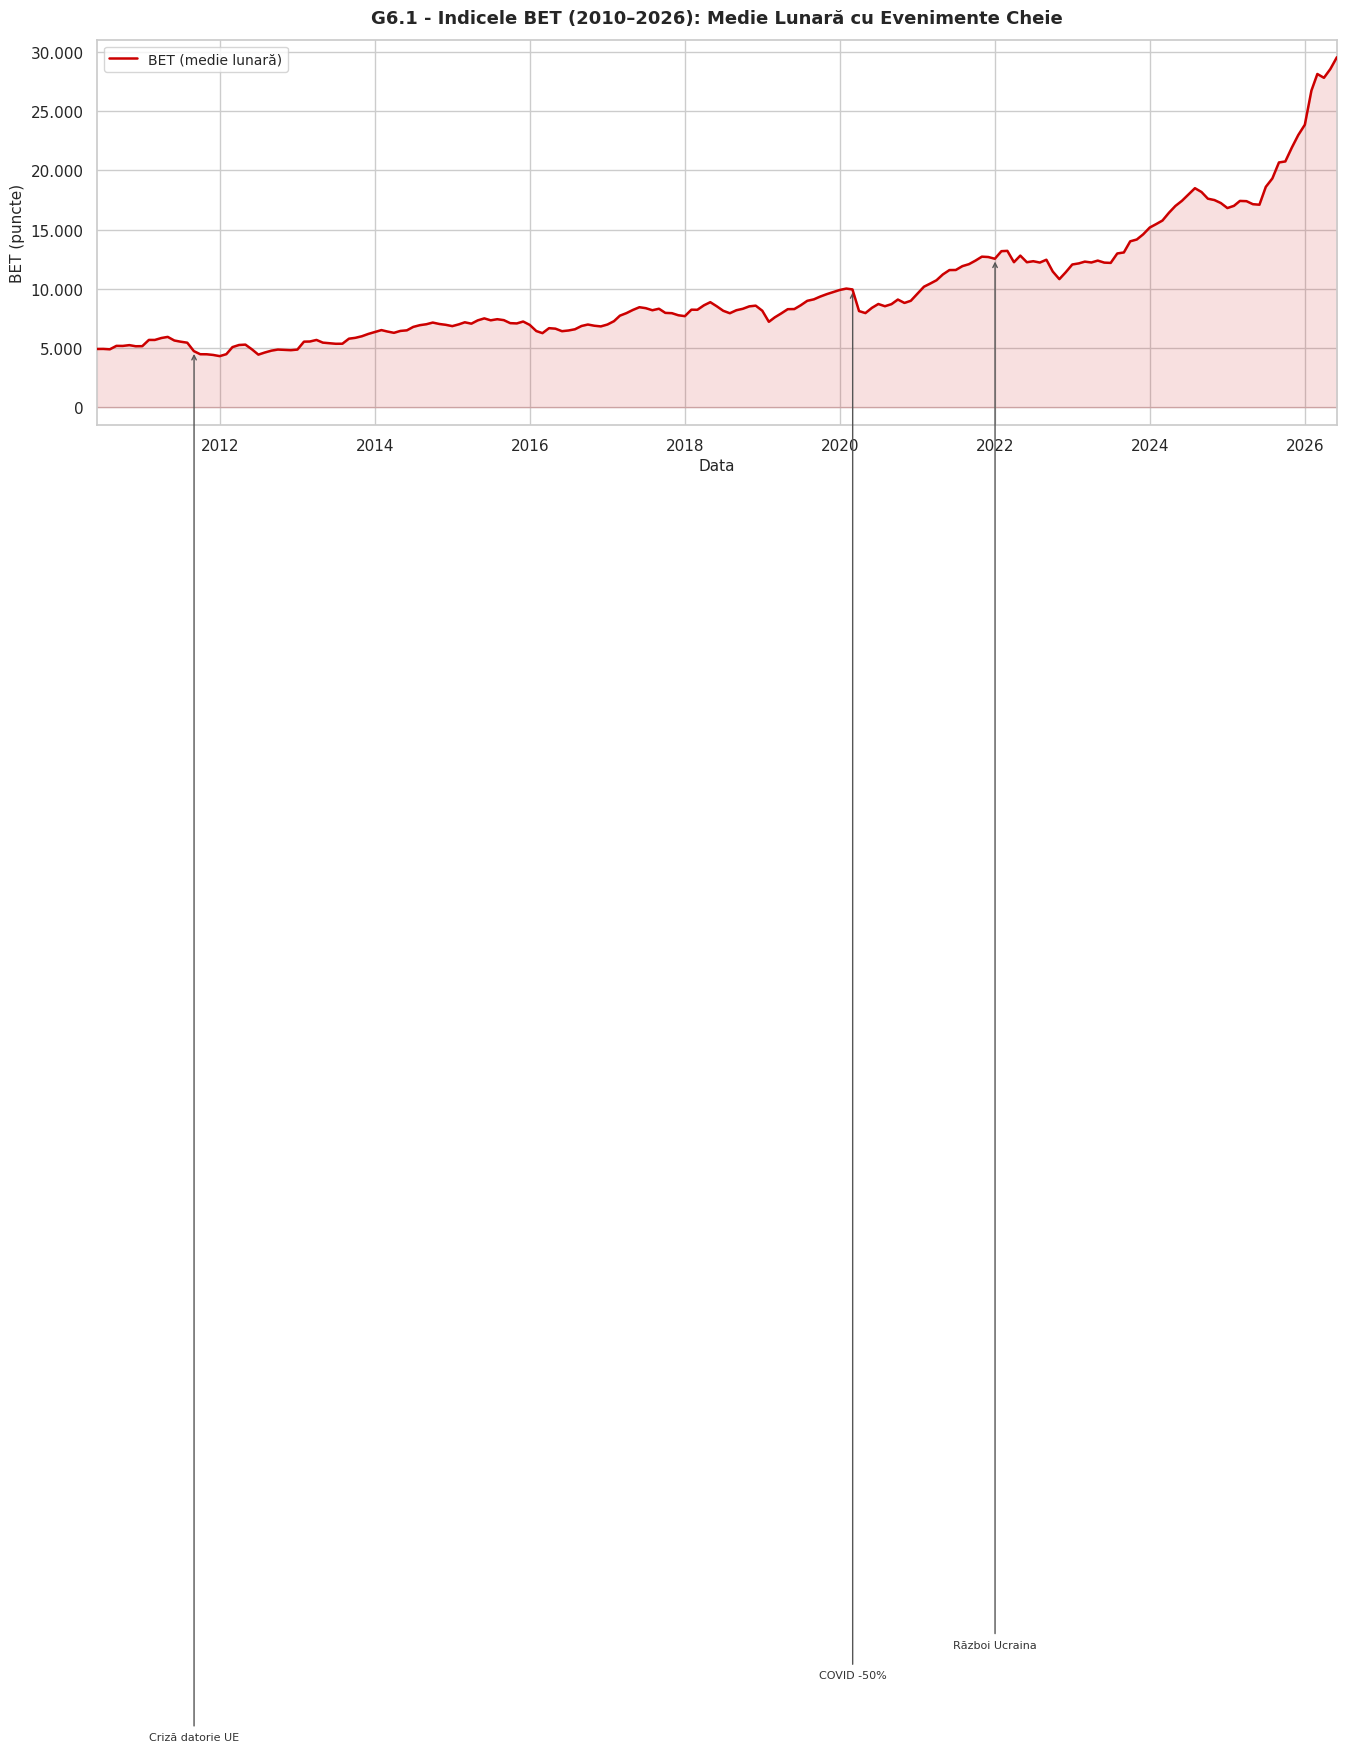

In [31]:
fig, ax = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_b = df_bet_lunar.copy()
ax.plot(df_b['data'], df_b['bet_pret'], color=CUL['ro'], linewidth=1.8, zorder=4, label='BET (medie lunară)')
ax.fill_between(df_b['data'], df_b['bet_pret'], alpha=0.12, color=CUL['ro'])

CRIZE_BET = [
    (pd.Timestamp('2011-09'), 'Criză datorie UE', -2000),
    (pd.Timestamp('2020-03'), 'COVID -50%', -2000),
    (pd.Timestamp('2022-01'), 'Război Ucraina', -2000),
]
for data, label, yoff in CRIZE_BET:
    y_val = df_b.loc[(df_b['data'] - data).abs().idxmin(), 'bet_pret']
    ax.annotate(label, xy=(data, y_val), xytext=(0, yoff + 1000),
                textcoords='offset points', ha='center', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1),
                color='#333333')

ax.set_xlabel('Data', fontsize=11)
ax.set_ylabel('BET (puncte)', fontsize=11)
ax.set_title('G6.1 - Indicele BET (2010–2026): Medie Lunară cu Evenimente Cheie', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'.replace(',','.')))
ax.set_xlim(df_b['data'].min(), df_b['data'].max())

plt.tight_layout()
plt.show()

#### G6.2 - Capitalizare BVB anuală (mld. RON) + PMI Eurozonă (ax dual)
**Tipul graficului:** Bare capitalizare + linie PMI pe ax dual  
**Mesajul:** Capitalizarea BVB crește accelerat după 2020 - parțial corelată cu PMI-ul Eurozonei.


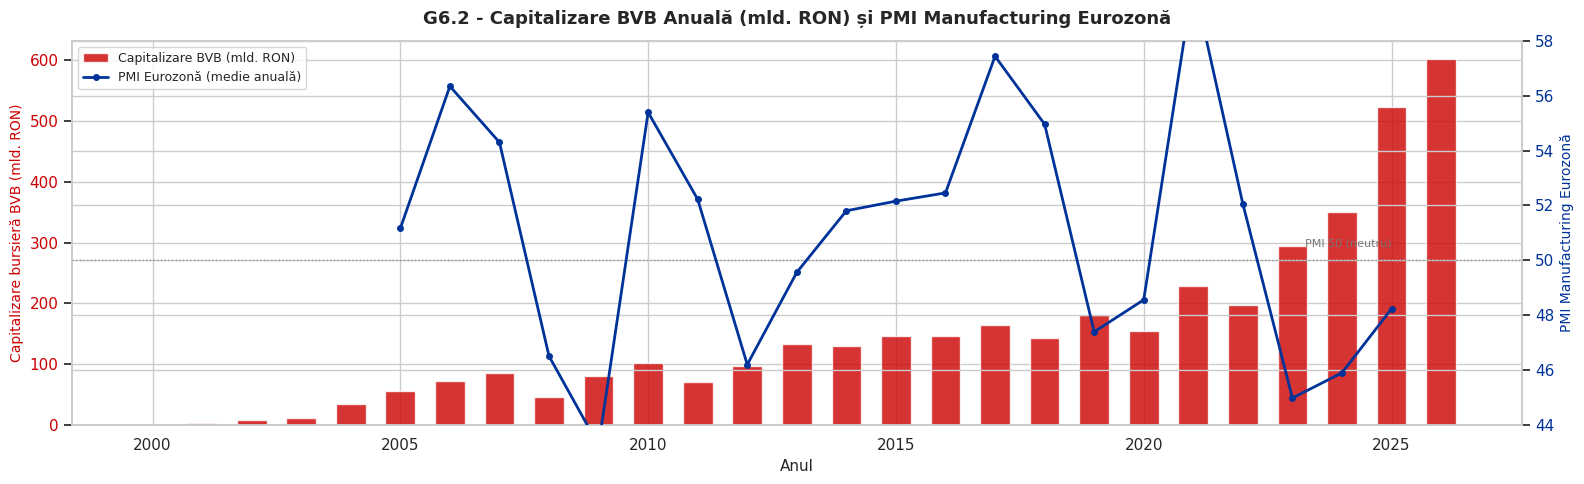

In [32]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_bp = df_bvb_pmi.dropna(subset=['capitalizare_mld_ron']).copy()

bars = ax1.bar(df_bp['an'], df_bp['capitalizare_mld_ron'],
               color=CUL['ro'], alpha=0.8, width=0.6, label='Capitalizare BVB (mld. RON)', zorder=3)
ax1.set_ylabel('Capitalizare bursieră BVB (mld. RON)', color=CUL['ro'], fontsize=10)
ax1.tick_params(axis='y', labelcolor=CUL['ro'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))

ax2 = ax1.twinx()
df_pmi_plot = df_bp.dropna(subset=['pmi_eurozona'])
ax2.plot(df_pmi_plot['an'], df_pmi_plot['pmi_eurozona'],
         color=CUL['ue'], linewidth=2, marker='o', markersize=4,
         label='PMI Eurozonă (medie anuală)', zorder=5)
ax2.axhline(y=50, color='#777777', linewidth=1, linestyle=':', alpha=0.7)
ax2.text(df_pmi_plot['an'].iloc[-1], 50.5, 'PMI 50 (neutru)', ha='right', fontsize=8, color='#777777')
ax2.set_ylabel('PMI Manufacturing Eurozonă', color=CUL['ue'], fontsize=10)
ax2.tick_params(axis='y', labelcolor=CUL['ue'])
ax2.set_ylim(44, 58)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_xlabel('Anul', fontsize=11)
ax1.set_title('G6.2 - Capitalizare BVB Anuală (mld. RON) și PMI Manufacturing Eurozonă', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

---
### 👥 Capitol 7 - Demografie: Bomba cu Ceas

Convergența economică se construiește pe un fundament care se surpă. România pierde simultan prin natalitate scăzută și emigrație masivă - un declin demografic structural.


#### G7.1 - Piramida Vârstelor: 2003 vs. 2024
**Tipul graficului:** Barh back-to-back (masculin stânga, feminin dreapta)  
**Mesajul:** Piramida s-a transformat dintr-o formă clasică în una de 'urnă' - baza s-a îngust semnificativ, vârful s-a lărgit.


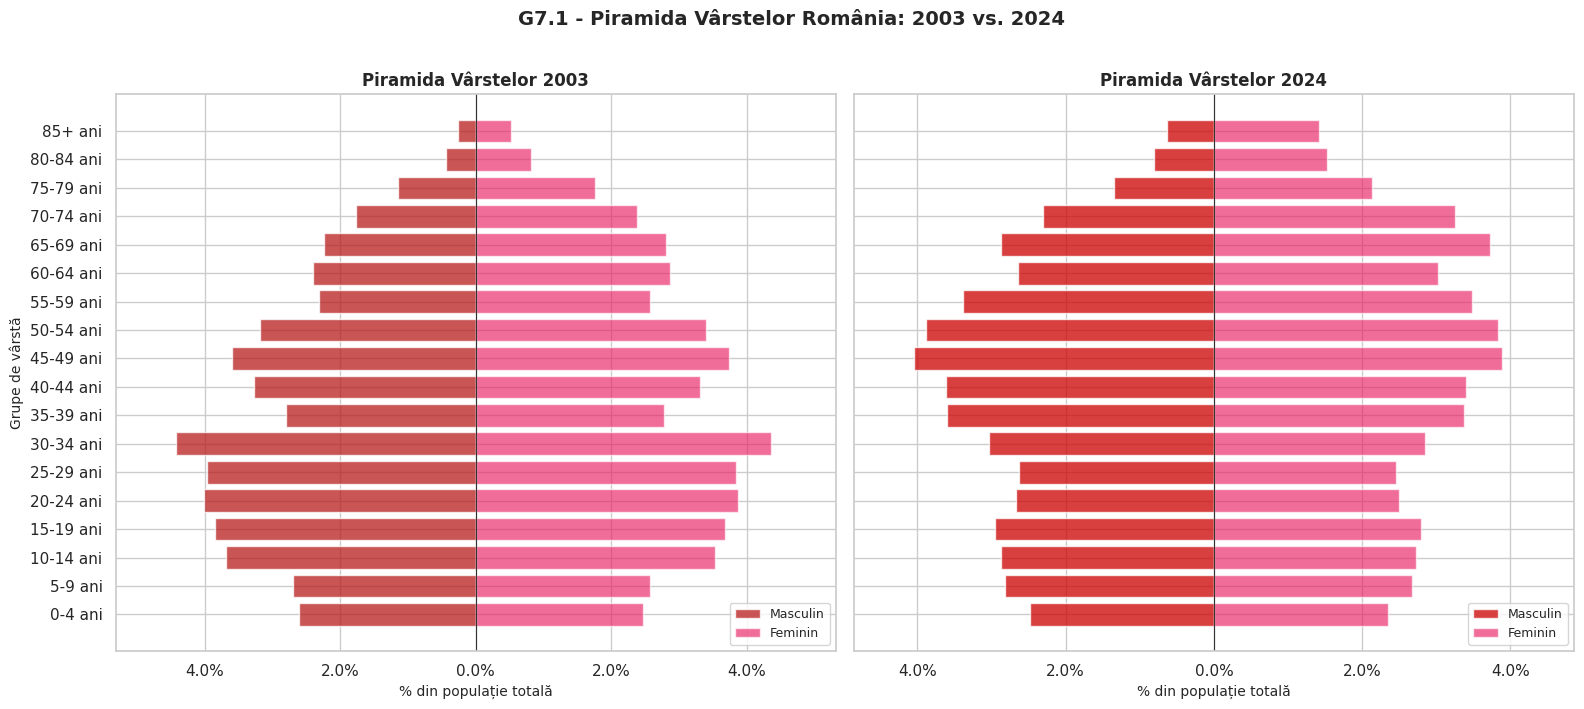

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sns.set(style='whitegrid')

for idx, an_ref in enumerate([2003, 2024]):
    ax = axes[idx]
    df_an = df_pop[df_pop['an'] == an_ref].copy()

    # Normalizare la % din populație totală
    total = df_an['populatie'].sum()
    grupe_ordonate = [g for g in ORDINE_GRUPE if g in df_an['grupa_varsta'].values]

    masc_vals, fem_vals, grupe_label = [], [], []
    for g in grupe_ordonate:
        m_val = df_an[(df_an['grupa_varsta']==g) & (df_an['sex']=='Masculin')]['populatie'].sum()
        f_val = df_an[(df_an['grupa_varsta']==g) & (df_an['sex']=='Feminin')]['populatie'].sum()
        masc_vals.append(-m_val / total * 100)
        fem_vals.append(f_val / total * 100)
        g_label = g.replace('sipeste','+').replace('_','-')
        grupe_label.append(g_label + ' ani')

    culoare = '#B71C1C' if an_ref == 2003 else '#CC0000'
    ax.barh(grupe_label, masc_vals, color=culoare, alpha=0.75, label='Masculin')
    ax.barh(grupe_label, fem_vals, color='#E91E63', alpha=0.65, label='Feminin')
    ax.axvline(x=0, color='#333333', linewidth=0.8)

    max_val = max(abs(min(masc_vals)), max(fem_vals)) * 1.2
    ax.set_xlim(-max_val, max_val)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(x):.1f}%'))
    ax.set_title(f'Piramida Vârstelor {an_ref}', fontsize=12, fontweight='bold')
    ax.set_xlabel('% din populație totală', fontsize=10)
    ax.legend(fontsize=9, loc='lower right')

    if idx == 0:
        ax.set_ylabel('Grupe de vârstă', fontsize=10)

fig.suptitle('G7.1 - Piramida Vârstelor România: 2003 vs. 2024', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### G7.2 - Rata Natalității (‰) și Migrație Netă anuală (ax dual)
**Tipul graficului:** Linie ax dual  
**Mesajul:** Natalitatea a scăzut de la 10.3‰ (2000) la 7.2‰ (2024). Migrația netă a intrat în teritoriu pozitiv abia din 2022 - posibil influx din Ucraina.


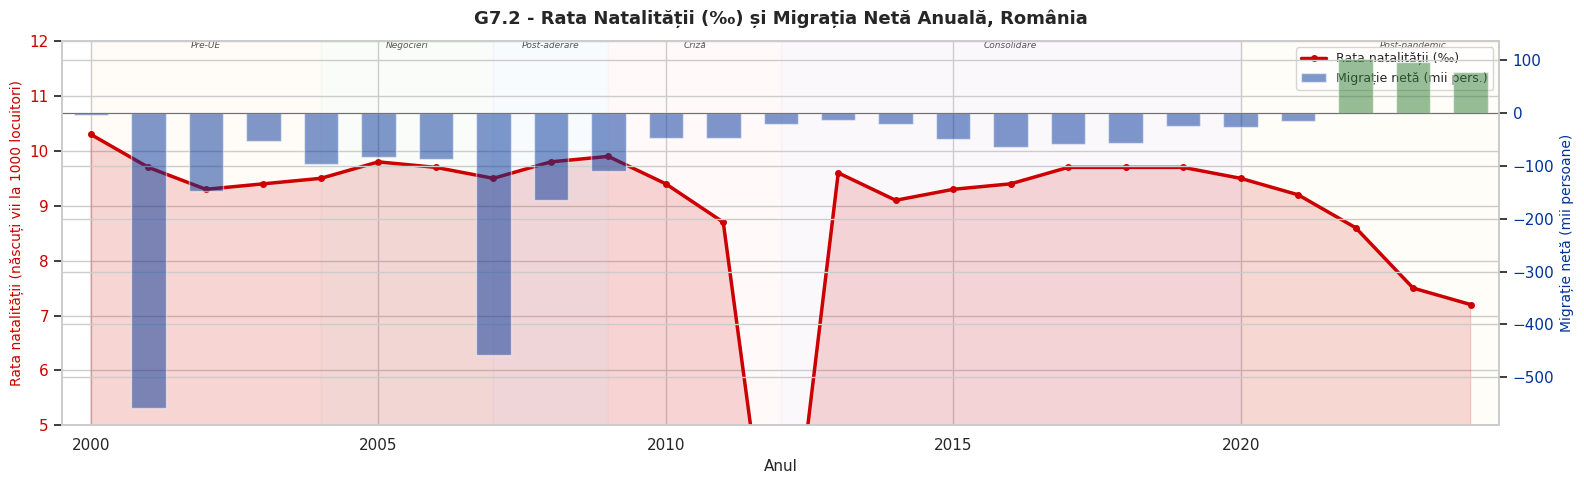

In [34]:
fig, ax1 = plt.subplots(figsize=FIGSIZE_W)
sns.set(style='whitegrid')

df_dm = df_demo.dropna(subset=['rata_natalitate_promil']).copy()

ax1.plot(df_dm['an'], df_dm['rata_natalitate_promil'],
         color=CUL['ro'], linewidth=2.5, marker='o', markersize=4,
         label='Rata natalității (‰)', zorder=4)
ax1.fill_between(df_dm['an'], df_dm['rata_natalitate_promil'], alpha=0.15, color=CUL['ro'])
ax1.set_ylabel('Rata natalității (născuți vii la 1000 locuitori)', color=CUL['ro'], fontsize=10)
ax1.tick_params(axis='y', labelcolor=CUL['ro'])
ax1.set_ylim(5, 12)

ax2 = ax1.twinx()
df_mig_plot = df_dm.dropna(subset=['migratie_neta'])
ax2.bar(df_mig_plot['an'], df_mig_plot['migratie_neta'] / 1000,
        color=[CUL['verde'] if v > 0 else CUL['ue'] for v in df_mig_plot['migratie_neta']],
        alpha=0.5, width=0.6, label='Migrație netă (mii pers.)', zorder=2)
ax2.axhline(y=0, color='#333333', linewidth=0.8, alpha=0.6)
ax2.set_ylabel('Migrație netă (mii persoane)', color=CUL['ue'], fontsize=10)
ax2.tick_params(axis='y', labelcolor=CUL['ue'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
ax1.set_xlabel('Anul', fontsize=11)
ax1.set_title('G7.2 - Rata Natalității (‰) și Migrația Netă Anuală, România', fontsize=13, fontweight='bold', pad=12)
adauga_ere(ax1, ymin=5, ymax=12)
ax1.set_xlim(df_dm['an'].min() - 0.5, df_dm['an'].max() + 0.5)

plt.tight_layout()
plt.show()

---
## 📌 PUNCTUL 4 - Dashboard Interactiv cu `ipywidgets` *(2p)*

Dashboard-ul permite explorarea a 6 indicatori macroeconomici cu control complet al perioadei, tipului de afișare și evidențierii erelor istorice.

**Controale disponibile:**
- `Dropdown` - Selectează indicatorul din 6 opțiuni
- `IntRangeSlider` - Interval de ani
- `RadioButtons` - Valori absolute vs. variație anuală (YoY)
- `ToggleButton` - Afișează / ascunde erele istorice
- `Button` + `Output` - Generează graficul


In [35]:
# ── Configurare dashboard ────────────────────────────────────────
INDICATORI = {
    'Rata Inflației Anuale (%)': {
        'df': 'inflatie_anuala', 'col': 'rata_inflatie_pct',
        'xcol': 'an', 'ylabel': 'Rata inflației (%)',
        'tip': 'anual', 'culoare': CUL['ro']
    },
    'EUR/RON - Curs Zilnic': {
        'df': 'curs_valutar', 'col': 'eur_ron',
        'xcol': 'data', 'ylabel': 'EUR/RON',
        'tip': 'zilnic', 'culoare': CUL['ro']
    },
    'Deficit Bugetar România (% PIB)': {
        'df': 'deficit_bugetar', 'col': 'deficit_ro_pct',
        'xcol': 'an', 'ylabel': 'Deficit (% PIB)',
        'tip': 'anual', 'culoare': CUL['rosu']
    },
    'Datorie Publică România (% PIB)': {
        'df': 'datorie_publica', 'col': 'datorie_ro_pct',
        'xcol': 'an', 'ylabel': 'Datorie (% PIB)',
        'tip': 'anual', 'culoare': CUL['portoc']
    },
    'Randament Obligațiuni 10Y România (%)': {
        'df': 'randament_10y', 'col': 'rand_ro_pct',
        'xcol': 'data', 'ylabel': 'Randament 10Y (%)',
        'tip': 'lunar', 'culoare': CUL['ue']
    },
    'PMI Manufacturing Eurozonă': {
        'df': 'pmi_lunar', 'col': 'pmi_eurozona',
        'xcol': 'data', 'ylabel': 'PMI (indice)',
        'tip': 'lunar', 'culoare': CUL['gri']
    },
}

# Map nume df → variabilă Python
DF_MAP = {
    'inflatie_anuala': df_inflatie,
    'curs_valutar':    df_curs,
    'deficit_bugetar': df_deficit,
    'datorie_publica': df_datorie,
    'randament_10y':   df_rand,
    'pmi_lunar':       df_pmi,
}

print("✓ Dashboard configurat cu", len(INDICATORI), "indicatori.")

✓ Dashboard configurat cu 6 indicatori.


In [36]:
# ── Construcție widget-uri ───────────────────────────────────────
st = {'description_width': 'initial'}
layout_w = pyw.Layout(width='420px')
layout_m = pyw.Layout(width='250px')

w_indicator = pyw.Dropdown(
    options=list(INDICATORI.keys()),
    description='📊 Indicator:',
    style=st, layout=layout_w
)

w_interval = pyw.IntRangeSlider(
    value=[2005, 2025],
    min=2000, max=2026, step=1,
    description='📅 Interval ani:',
    continuous_update=False,
    style=st, layout=layout_w
)

w_tip = pyw.RadioButtons(
    options=['Valori absolute', 'Variație YoY (%)'],
    description='📈 Tip afișare:',
    style=st, layout=layout_m
)

w_ere = pyw.ToggleButton(
    value=True,
    description='Afișează ere istorice',
    button_style='info',
    icon='check',
    layout=pyw.Layout(width='200px')
)

w_btn = pyw.Button(
    description='🔄 Generează grafic',
    button_style='primary',
    layout=pyw.Layout(width='200px')
)

w_err = pyw.Label(value='', style={'text_color': 'red'})
w_out = pyw.Output(layout={'border': '1px solid #e0e0e0', 'padding': '8px'})

# ── Funcție de afișare ───────────────────────────────────────────
def afisare_grafic(b=None):
    w_err.value = ''
    with w_out:
        w_out.clear_output(wait=True)

        cfg = INDICATORI[w_indicator.value]
        df_base = DF_MAP[cfg['df']].copy()
        xcol = cfg['xcol']
        col  = cfg['col']
        an_i, an_f = w_interval.value

        # Filtrare perioadă
        if xcol == 'an':
            df_f = df_base[(df_base['an'] >= an_i) & (df_base['an'] <= an_f)].dropna(subset=[col])
            x_vals = df_f['an']
        else:
            if xcol == 'data' and df_base[xcol].dtype == 'object':
                df_base[xcol] = pd.to_datetime(df_base[xcol])
            df_f = df_base[
                (df_base[xcol].dt.year >= an_i) & (df_base[xcol].dt.year <= an_f)
            ].dropna(subset=[col])
            x_vals = df_f[xcol]

        if len(df_f) < 2:
            w_err.value = '⚠ Date insuficiente pentru perioada selectată.'
            return

        y_vals = df_f[col].copy()
        ylabel = cfg['ylabel']

        # Variație YoY
        if w_tip.value == 'Variație YoY (%)':
            if xcol == 'an':
                y_vals = y_vals.pct_change() * 100
            else:
                y_vals = y_vals.pct_change(12) * 100
            ylabel = 'Variație anuală (%)'

        # Grafic
        fig, ax = plt.subplots(figsize=(15, 5))
        sns.set(style='whitegrid')

        ax.plot(x_vals, y_vals, color=cfg['culoare'], linewidth=2, zorder=4)
        ax.fill_between(x_vals, y_vals, alpha=0.12, color=cfg['culoare'])

        # Ere istorice
        if w_ere.value and xcol == 'an':
            for start, end, culoare, label in ERE:
                if end >= an_i and start <= an_f:
                    ax.axvspan(max(start, an_i), min(end, an_f), alpha=0.2, color=culoare, zorder=0)
                    mid = (max(start, an_i) + min(end, an_f)) / 2
                    ax.text(mid, ax.get_ylim()[1], label, ha='center', va='top',
                            fontsize=7, color='#666666', style='italic')

        # Linie zero
        if y_vals.min() < 0 < y_vals.max():
            ax.axhline(y=0, color='#333333', linewidth=0.8, linestyle='-', alpha=0.5)

        ax.set_xlabel('Perioada', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{w_indicator.value} ({an_i}–{an_f})', fontsize=13, fontweight='bold', pad=12)

        # Statistici în titlu secundar
        ax.set_xlabel(f'Min: {y_vals.min():.2f} | Max: {y_vals.max():.2f} | Medie: {y_vals.mean():.2f}', fontsize=9)

        plt.tight_layout()
        plt.show()

w_btn.on_click(afisare_grafic)
w_indicator.observe(afisare_grafic, names='value')

# ── Layout dashboard ──────────────────────────────────────────────
rand1 = pyw.HBox([w_indicator])
rand2 = pyw.HBox([w_interval])
rand3 = pyw.HBox([w_tip, pyw.VBox([w_ere, w_btn])])
rand4 = pyw.HBox([w_err])

dashboard = pyw.VBox([
    pyw.HTML('<h3 style="color:#CC0000">📊 Dashboard Macroeconomic România</h3>'),
    rand1, rand2, rand3, rand4, w_out
])
display(dashboard)
afisare_grafic()

---
## 📌 PUNCTUL 5 - Concluzii și Interpretări *(1.5p)*

### 5.1 Sinteza celor 4 acte narative

**Actul I (2000–2007):** România a demarat tranziția cu inflație de 45% și un PIB nominal sub 50 mld. USD. Aderarea la UE în 2007 a reprezentat catalizatorul structural pentru o decadă de convergență accelerată.

**Actul II (2007–2012):** Boomul post-aderare a expus rapid vulnerabilitățile: deficit bugetar explodat la -9.5% în 2009, depreciere bruscă a leului, șomaj în creștere. Criza globală a lovit Romania mai puternic decât media UE-27.

**Actul III (2012–2021):** Consolidare fragilă - creștere economică reluată, salarii în expansiune, BET pe un trend ascendent. Dar deficitul bugetar a reapărut structural din 2016, pe fondul majorărilor salariale în sectorul public.

**Actul IV (2021–2026):** Inflație record (16.4% în nov. 2022), dobânzi BNR la maximul ultimilor 15 ani, deficit bugetar de -9.3% din PIB în 2024 - cel mai mare din UE. Rezervele BNR (78 mld. EUR) rămân scudul de protecție, iar BVB atinge maximuri istorice.

---

### 5.2 Top 5 Insights din Datele Vizualizate

1. **EUR/RON - anomalia regională:** În timp ce EUR/HUF a crescut cu 60% față de 2005, EUR/RON a crescut cu doar ~17%. Această stabilitate anormală ascunde fie o politică monetară activă a BNR, fie o supraapreciere care va fi corectată.

2. **Deficitul bugetar - problemă structurală, nu conjuncturală:** România a depășit limita de -3% Maastricht în 7 ani din ultimii 10. Nu e vorba de crize externe - e vorba de cheltuieli publice neacoperite de venituri fiscale (printre cele mai mici din UE ca % PIB).

3. **Piramida vârstelor - transformare dramatică:** Baza piramidei (0–14 ani) s-a redus cu ~30% față de 2003. Sistemul de pensii va fi insolvent structural înainte de 2040 dacă traiectoria actuală continuă.

4. **BVB - creștere reală, nu bule:** Capitalizarea BVB a crescut de la 1 mld. RON (2000) la 600 mld. RON (2026) - o creștere de 600×. Totuși, ca % din PIB, rămâne la 40-50% față de 100%+ în economiile dezvoltate.

5. **Câștigul salarial vs. PIB:** Salariul mediu net a crescut de ~34× în 25 de ani, față de PIB nominal care a crescut de ~10×. Această divergență reflectă câștiguri reale de productivitate, dar și presiuni inflaționiste structurale.

---

### 5.3 Limitele Analizei

- Datele IPC lunar sunt variații față de luna anterioară (MoM), nu față de același an (YoY) - comparabilitatea directă cu inflația anuală necesită compunere
- Câștigul salarial lunar acoperă doar totalul economiei - diferențele intersectoriale (IT vs. agricultură) nu sunt vizualizate
- Piramida vârstelor pornește din 2003 (limita datelor INS disponibile), nu din 2000
- Indicele BET pornește din 2010 - episodul critic 2008–2009 nu apare în graficul de capital

---

### 5.4 Întrebări Deschise Generate de Date

- Va reuși România să iasă din procedura de deficit excesiv până în 2030 fără o ajustare fiscală dureroasă?
- Când va atinge EUR/RON pragul psihologic de 5.0 - și ce se va întâmpla cu inflația?
- Poate piața de capital românească să compenseze deficitul demografic prin creșterea avuției populației?
